In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# PUNTO 1-2-3

## 1. El Fenómeno de Hurst y el Exponente de Hurst (H)

### Fenómeno de Hurst
Es la observación empírica de que en muchos registros geofísicos (como el caudal del río Nilo), el **rango reescalado**, denotado como \( R(s)/S(s) \), no sigue la regla estadística clásica de la raíz cuadrada del tiempo \( \sqrt{s} \).

En su lugar, el rango de los datos crece mucho más rápido de lo esperado en modelos de **memoria corta**.

### Exponente de Hurst (H)
Es la constante numérica que describe esta tasa de crecimiento. Se define mediante la relación:

\[
\frac{R(s)}{S(s)} \propto s^{H}
\]

- Un valor de \( H = 0.5 \) indica un proceso puramente aleatorio e independiente (movimiento Browniano).
- Hurst descubrió que para los ríos, \( H \approx 0.7 \), aunque puede ser superior a \( 0.85 \).
- Esto evidencia **persistencia** o **memoria de largo plazo** en los datos.

## 2. El "Efecto José" en Hidrología Operacional

Se refiere a la observación de que periodos de precipitación inusual (alta o baja) pueden ser **extremadamente largos**.

- Describe la **persistencia a largo plazo** de ciclos climáticos.
- Un año seco tiende a ser seguido por otro año seco.
- Se forman **rachas prolongadas** que desafían modelos estadísticos convencionales.
- El promedio de la serie tarda mucho tiempo en estabilizarse.

## 3. El "Efecto Noé" en Hidrología Operacional

Designa el hecho de que la precipitación extrema puede ser **muy extrema**.

- Se refiere a eventos individuales o de corta duración (ej. inundaciones catastróficas).
- Estos eventos afectan el promedio durante muchos años.
- Aparecen como **valores atípicos (outliers)**.
- Ocurren con mayor frecuencia de la predicha por una distribución normal (Gaussiana).

## 4. Recreación de pasajes de *"José y sus hermanos"*

A continuación, se presentan escenas inspiradas en el relato bíblico para ilustrar estos conceptos:

## Escena I: El Efecto José (La Profecía de los Ciclos Largos)

**Contexto:** José interpreta el sueño del Faraón sobre las siete vacas gordas y las siete vacas flacas.

> **Faraón:**  
> "He tenido un sueño que nadie puede explicar. Siete vacas hermosas y robustas salían del río, pero tras ellas venían siete vacas feas y flacas que devoraban a las primeras."

> **José:**  
> "El sueño es uno solo. Dios te muestra lo que va a hacer. Vendrán siete años de gran abundancia en toda la tierra de Egipto. Pero tras ellos vendrán siete años de hambre, y el hambre consumirá la tierra."

### Explicación hidrológica
Esta escena ilustra el **Efecto José**:

- No es un evento puntual, sino una **tendencia persistente**.
- Representa ciclos largos de abundancia o escasez.
- Matemáticamente:
  - Se asocia con \( H > 0.5 \)
  - Indica dependencia temporal (memoria).

## Escena II: El Efecto Noé (La Inundación Extrema)

**Contexto:** El inicio del diluvio universal.

> **Narrador:**  
> "En aquel día fueron rotas todas las fuentes del gran abismo, y las cataratas del cielo se abrieron."

> **Noé (desde el arca):**  
> "La lluvia no cesa. Ha caído sobre la tierra cuarenta días y cuarenta noches con una fuerza nunca antes vista."

### Explicación hidrológica
Esta escena ilustra el **Efecto Noé**:

- Evento **catastrófico y extremo**.
- Supera cualquier comportamiento esperado basado en promedios.
- Implica que:
  - Las "inundaciones del milenio" ocurren más seguido de lo esperado.
  - Un solo evento puede **redefinir la estadística** de una cuenca.

## Tabla Comparativa: Efecto Noé vs. Efecto José

| Característica | Efecto Noé | Efecto José |
|--------------|-----------|-------------|
| **Definición Principal** | La precipitación extrema puede ser muy extrema en magnitud. | Un periodo de precipitación inusual puede ser extremadamente largo en duración. |
| **Foco Hidrológico** | Se centra en la intensidad de eventos individuales (inundaciones). | Se centra en la persistencia de tendencias (sequías o años húmedos). |
| **Frecuencia Relativa** | Designa fenómenos de "alta frecuencia" dentro de la escala de análisis. | Designa fenómenos de "baja frecuencia" o de larga longitud de onda. |
| **Impacto en los Datos** | Genera "outliers" (valores atípicos) distantes en los histogramas de escorrentía. | Produce un comportamiento "errático" donde los promedios tardan mucho en estabilizarse. |
| **Comportamiento Estadístico** | Las "inundaciones del milenio" ocurren con mayor frecuencia que la predicha por una distribución normal. | Rompe la "ley de la raíz de s"; el rango de los datos crece según la Ley de Hurst \( s^H \). |
| **Relación con el Modelo Gaussiano** | Se aleja de lo Gaussiano debido a las colas pesadas de la distribución (eventos extremos). | Puede ocurrir incluso en procesos Gaussianos si presentan memoria de largo plazo persistente. |
| **Referencia Bíblica** | El Diluvio: evento catastrófico de corta duración pero gran magnitud. | Las Vacas Flacas/Gordas: ciclos de abundancia y escasez que duran muchos años. |

# PUNTO 2

In [7]:
df_q = pd.read_csv(r".\35107030_C.csv")

# Asegurar formato fecha
df_q["Fecha"] = pd.to_datetime(df_q["Fecha"])

# Ordenar
df_q = df_q.sort_values("Fecha")

# Indexar
df_q = df_q.set_index("Fecha")

# Agregar a diario (promedio)
df_daily = df_q["Valor"].resample("D").mean()

# Eliminar días sin datos
df_daily = df_daily.dropna()

print("Número de días:", len(df_daily))
print("Años aproximados:", len(df_daily)/365)

Número de días: 7958
Años aproximados: 21.802739726027397


In [ ]:
serie = df_daily.dropna()
x = serie.values
# x = (x - np.mean(x)) / np.std(x)

In [9]:
def mutual_information(x, y, bins=30):
    joint_hist, _, _ = np.histogram2d(x, y, bins=bins)
    
    # Probabilidad conjunta
    pxy = joint_hist / np.sum(joint_hist)
    
    # Marginales
    px = np.sum(pxy, axis=1)
    py = np.sum(pxy, axis=0)
    
    mi = 0.0
    for i in range(len(px)):
        for j in range(len(py)):
            if pxy[i, j] > 0 and px[i] > 0 and py[j] > 0:
                mi += pxy[i, j] * np.log(pxy[i, j] / (px[i] * py[j]))
    
    return mi

In [10]:
def nonlinear_acf(series, max_lag=100, bins=30):
    mi_values = []
    
    for lag in range(1, max_lag + 1):
        x1 = series[:-lag]
        x2 = series[lag:]
        
        mi = mutual_information(x1, x2, bins=bins)
        mi_values.append(mi)
    
    return np.array(mi_values)

In [14]:
max_lag = 120  # ~4 meses en días

mi_vals = nonlinear_acf(x, max_lag=max_lag)
lags = np.arange(1, max_lag + 1)

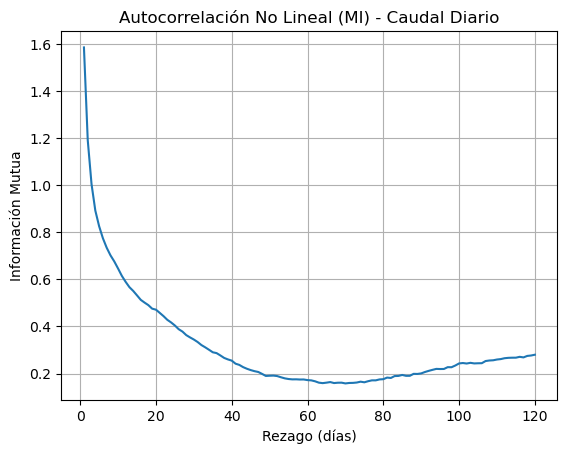

In [15]:
plt.figure()
plt.plot(lags, mi_vals)
plt.xlabel("Rezago (días)")
plt.ylabel("Información Mutua")
plt.title("Autocorrelación No Lineal (MI) - Caudal Diario")
plt.grid()
plt.show()

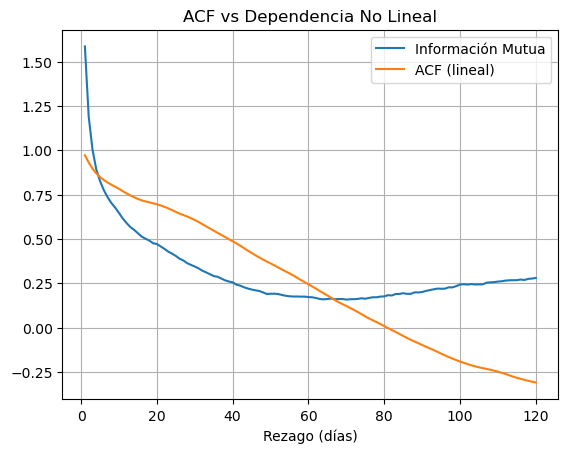

In [16]:
from statsmodels.tsa.stattools import acf

acf_vals = acf(x, nlags=max_lag)

plt.figure()
plt.plot(lags, mi_vals, label="Información Mutua")
plt.plot(lags, acf_vals[1:], label="ACF (lineal)")
plt.legend()
plt.xlabel("Rezago (días)")
plt.title("ACF vs Dependencia No Lineal")
plt.grid()
plt.show()

# PUNTO 3

In [18]:
# Asegurar índice tipo fecha
df_daily.index = pd.to_datetime(df_daily.index)

# Serie mensual (puedes usar mean o sum según enfoque hidrológico)
caudal_mensual = df_daily.resample('ME').mean()

# Eliminar NaN
caudal_mensual = caudal_mensual.dropna()

In [20]:
oni = pd.read_csv(
    "oni.ascii",
    sep=r"\s+",
    comment=';',
    engine="python"
)

oni_df = oni[["YR", "MON", "ANOM.3"]].copy()
oni_df.columns = ["Year", "Month", "ONI"]

In [21]:
oni = oni_df.copy()

oni["date"] = pd.to_datetime(
    dict(year=oni["Year"], month=oni["Month"], day=1)
) + pd.offsets.MonthEnd(0)

oni = oni.set_index("date")["ONI"].asfreq("ME")

In [22]:
df_combined = pd.concat([caudal_mensual, oni], axis=1).dropna()

# Extraer arrays
q = df_combined.iloc[:, 0].values  # caudal
oni_vals = df_combined.iloc[:, 1].values

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_23204\2623809895.py:1: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df_combined = pd.concat([caudal_mensual, oni], axis=1).dropna()


In [23]:
def mutual_information(x, y, bins=20):
    joint_hist, _, _ = np.histogram2d(x, y, bins=bins)
    
    pxy = joint_hist / np.sum(joint_hist)
    px = np.sum(pxy, axis=1)
    py = np.sum(pxy, axis=0)
    
    mi = 0.0
    for i in range(len(px)):
        for j in range(len(py)):
            if pxy[i, j] > 0 and px[i] > 0 and py[j] > 0:
                mi += pxy[i, j] * np.log(pxy[i, j] / (px[i] * py[j]))
    
    return mi

In [25]:
def cross_mi(caudal, oni, max_lag=24, bins=20):
    mi_vals = []
    lags = range(-max_lag, max_lag + 1)
    
    for lag in lags:
        if lag < 0:
            x = caudal[:lag]
            y = oni[-lag:]
        elif lag > 0:
            x = caudal[lag:]
            y = oni[:-lag]
        else:
            x = caudal
            y = oni
        
        mi = mutual_information(x, y, bins=bins)
        mi_vals.append(mi)
    
    return np.array(list(lags)), np.array(mi_vals)

In [26]:
lags, mi_vals = cross_mi(q, oni_vals, max_lag=24)

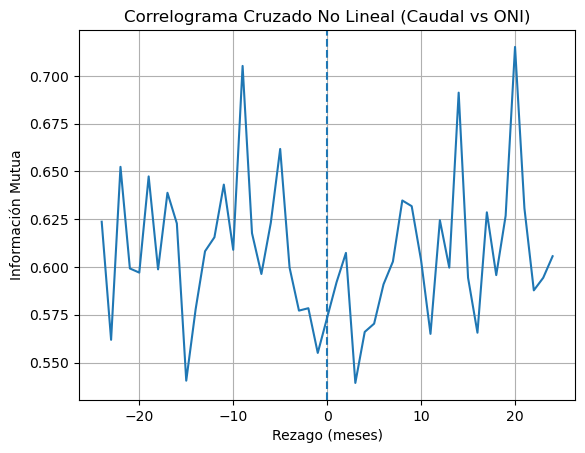

In [27]:
plt.figure()
plt.plot(lags, mi_vals)
plt.axvline(0, linestyle='--')
plt.xlabel("Rezago (meses)")
plt.ylabel("Información Mutua")
plt.title("Correlograma Cruzado No Lineal (Caudal vs ONI)")
plt.grid()
plt.show()

In [29]:
def cross_corr(x, y, max_lag=24):
    corr_vals = []
    lags = range(-max_lag, max_lag + 1)
    
    for lag in lags:
        if lag < 0:
            x1 = x[:lag]
            y1 = y[-lag:]
        elif lag > 0:
            x1 = x[lag:]
            y1 = y[:-lag]
        else:
            x1 = x
            y1 = y
        
        corr = np.corrcoef(x1, y1)[0,1]
        corr_vals.append(corr)
    
    return np.array(list(lags)), np.array(corr_vals)

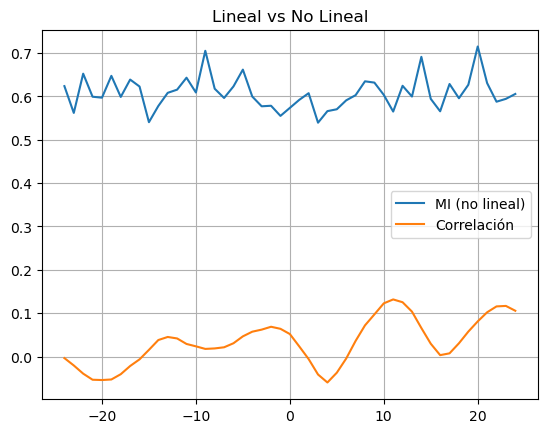

In [30]:
lags, corr_vals = cross_corr(q, oni_vals)

plt.figure()
plt.plot(lags, mi_vals, label="MI (no lineal)")
plt.plot(lags, corr_vals, label="Correlación")
plt.legend()
plt.title("Lineal vs No Lineal")
plt.grid()
plt.show()

# PUNTO 4

In [40]:
# Cargar datos
hr = pd.read_csv("35105050_HR.csv")

# Convertir fecha
hr['Fecha'] = pd.to_datetime(hr['Fecha'])

# Filtrar columna de valor
hr = hr[['Fecha', 'Valor']].rename(columns={'Valor': 'hr'})

# Indexar
hr = hr.set_index('Fecha')

# Pasar a mensual (promedio)
hr_mensual = hr.resample('ME').mean().dropna()

hr_mensual = hr_mensual.squeeze()

In [34]:
df_q = pd.read_csv(r".\35107030_P.csv")

# Asegurar formato fecha
df_q["Fecha"] = pd.to_datetime(df_q["Fecha"])

# Ordenar
df_q = df_q.sort_values("Fecha")

# Indexar
df_q = df_q.set_index("Fecha")

# Agregar a diario (promedio)
df_daily = df_q["Valor"].resample("D").mean()

# Eliminar días sin datos
df_daily = df_daily.dropna()

print("Número de días:", len(df_daily))
print("Años aproximados:", len(df_daily)/365)

Número de días: 9330
Años aproximados: 25.561643835616437


In [35]:
# Precipitación mensual (suma)
precip_mensual = df_daily.resample("ME").sum()

In [36]:
# Asegurar índices
caudal_mensual.index = pd.to_datetime(caudal_mensual.index)
precip_mensual.index = pd.to_datetime(precip_mensual.index)

In [41]:
df_all = pd.concat([
    caudal_mensual.rename("caudal"),
    precip_mensual.rename("precip"),
    hr_mensual.rename("hr")
], axis=1).dropna()

In [42]:
df_norm = (df_all - df_all.mean()) / df_all.std()

q = df_norm["caudal"].values
p = df_norm["precip"].values
h = df_norm["hr"].values

In [43]:
lags, mi_precip = cross_mi(p, q, max_lag=24)
_, mi_hr = cross_mi(h, q, max_lag=24)

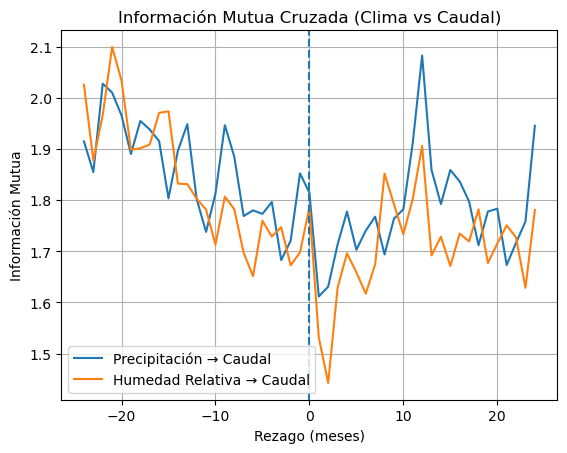

In [44]:
plt.figure()

plt.plot(lags, mi_precip, label="Precipitación → Caudal")
plt.plot(lags, mi_hr, label="Humedad Relativa → Caudal")

plt.axvline(0, linestyle='--')
plt.xlabel("Rezago (meses)")
plt.ylabel("Información Mutua")
plt.title("Información Mutua Cruzada (Clima vs Caudal)")
plt.legend()
plt.grid()

plt.show()